
<div style="
background-color:#F3E5F5;
padding:25px;
border-radius:10px;
border:2px solid #9C27B0;
text-align:center;
">

<h1 style="margin:0; color:#6A1B9A;">
AI-Powered Support Ticket Classification, Priority Prediction & Smart Routing
</h1>

<h2 style="margin:12px 0 5px; color:#7B1FA2;">
Machine Learning Internship Project
</h2>

<h2 style="margin:0; color:#8E24AA;">
Task 2
</h2>

</div>


### Project Objectives

This project develops an AI-based support ticket management system that can:

1. Automatically classify customer support tickets.
2. Predict ticket priority.
3. Analyze customer sentiment.
4. Compare multiple Machine Learning algorithms.
5. Optimize the best-performing model.
6. Evaluate model performance using multiple metrics.
7. Perform error analysis.
8. Provide confidence-aware predictions.
9. Automatically recommend the appropriate support team.
10. Save trained models for future deployment.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- NLP
- TF-IDF
- Machine Learning
- Joblib
- Streamlit-ready model pipeline

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import warnings
warnings.filterwarnings("ignore")

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import sys
import sklearn
import pandas

print("Python Version:", sys.version)
print("Pandas Version:", pandas.__version__)
print("Scikit-learn Version:", sklearn.__version__)

Python Version: 3.14.6 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:05) [MSC v.1942 64 bit (AMD64)]
Pandas Version: 3.0.3
Scikit-learn Version: 1.9.0


In [6]:
import os
import glob
import pandas as pd

folder_path = r"C:\Users\shaik\Downloads\archive (6)"

# Find CSV files inside the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

print("CSV files found:")
for file in csv_files:
    print(file)

# Load the first CSV file
df = pd.read_csv(csv_files[0])

print("\nDataset loaded successfully!")


CSV files found:
C:\Users\shaik\Downloads\archive (6)\customer_support_tickets.csv

Dataset loaded successfully!


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (8469, 17)

Column Names:
['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']

First 5 Rows:


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


## DATA UNDERSTANDING

### Dataset Information

In [8]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nDataset Information:")
df.info()

Number of Rows: 8469
Number of Columns: 17

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket P

### Missing Values

In [9]:
missing = df.isnull().sum()

print("Missing Values:")
print(missing)

Missing Values:
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64


### Duplicate Records

In [10]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


## Remove Duplicates and Missing Values

In [11]:
df = df.drop_duplicates()

df = df.dropna(
    subset=[
        TEXT_COLUMN,
        CATEGORY_COLUMN,
        PRIORITY_COLUMN
    ]
)

print("Dataset after cleaning:")
print(df.shape)

Dataset after cleaning:
(8469, 17)


## Basic Statistics

In [12]:
df.describe(include="all")

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
count,8469.000000,8469,8469,8469.000000,8469,8469,8469,8469,8469,8469,8469,2769,8469,8469,5650,2769,2769.000000
unique,NaN,8028,8320,NaN,3,42,730,5,16,8077,3,2769,4,4,5470,2728,NaN
top,NaN,Michael Garcia,asmith@example.com,NaN,Male,Canon EOS,2020-10-21,Refund request,Refund request,I'm having an issue with the {product_purchase...,Pending Customer Response,Case maybe show recently my computer follow.,Medium,Email,2023-06-01 01:21:19,2023-06-01 17:14:42,NaN
freq,NaN,5,4,NaN,2896,240,24,1752,576,25,2881,1,2192,2143,3,3,NaN
mean,4235.000000,NaN,NaN,44.026804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.991333
std,2444.934048,NaN,NaN,15.296112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.407016
min,1.000000,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
25%,2118.000000,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000
50%,4235.000000,NaN,NaN,44.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000
75%,6352.000000,NaN,NaN,57.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000


## EXPLORATORY DATA ANALYSIS

### Category Distribution

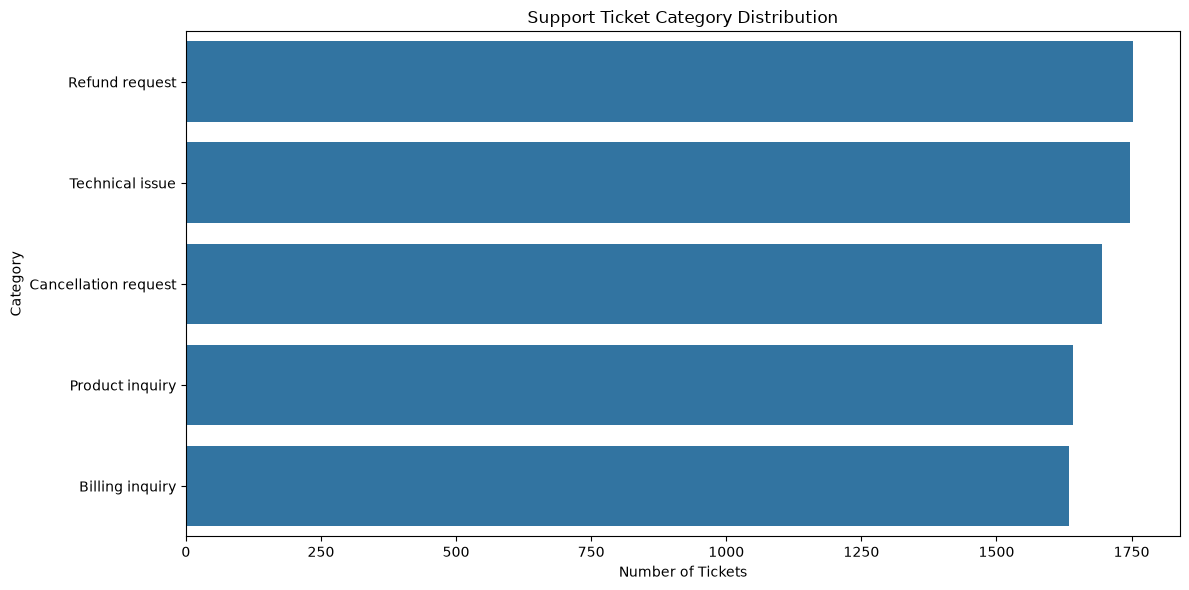

In [13]:
plt.figure(figsize=(12, 6))

category_counts = df[CATEGORY_COLUMN].value_counts()

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title("Support Ticket Category Distribution")
plt.xlabel("Number of Tickets")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### Priority Distribution

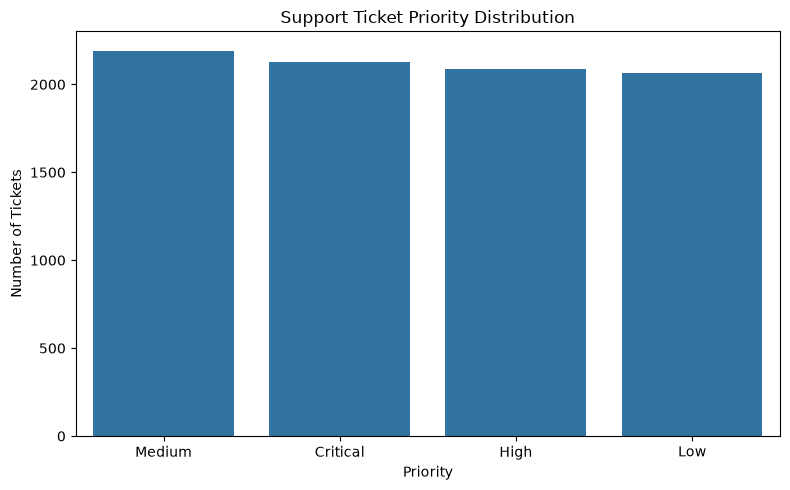

In [14]:
plt.figure(figsize=(8, 5))

priority_counts = df[PRIORITY_COLUMN].value_counts()

sns.barplot(
    x=priority_counts.index,
    y=priority_counts.values
)

plt.title("Support Ticket Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

## Category vs Priority

In [15]:
cross_table = pd.crosstab(
    df[CATEGORY_COLUMN],
    df[PRIORITY_COLUMN]
)

display(cross_table)

Ticket Priority,Critical,High,Low,Medium
Ticket Type,,,,
Billing inquiry,420,382,398,434
Cancellation request,423,398,414,460
Product inquiry,403,399,398,441
Refund request,444,448,440,420
Technical issue,439,458,413,437


## Category vs Priority Heatmap

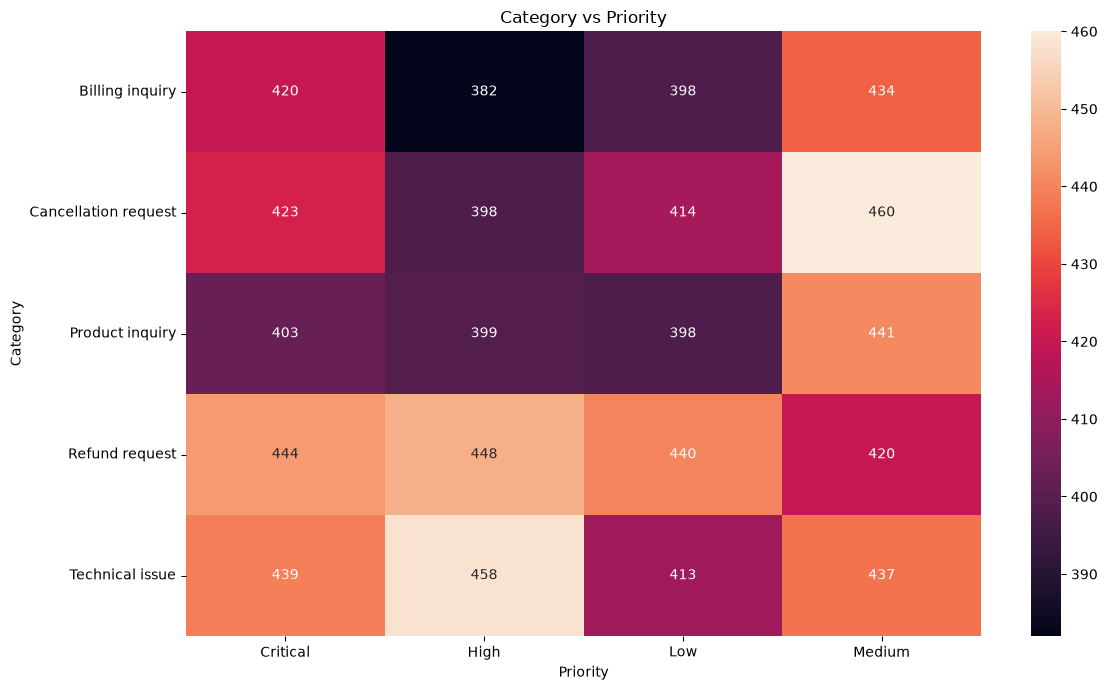

In [16]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    cross_table,
    annot=True,
    fmt="d"
)

plt.title("Category vs Priority")
plt.xlabel("Priority")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

## Text Length

In [17]:
df["text_length"] = (
    df[TEXT_COLUMN]
    .astype(str)
    .apply(len)
)

print(df["text_length"].describe())

count    8469.000000
mean      289.821939
std        43.593954
min       151.000000
25%       273.000000
50%       298.000000
75%       318.000000
max       397.000000
Name: text_length, dtype: float64


## Text Length Distribution

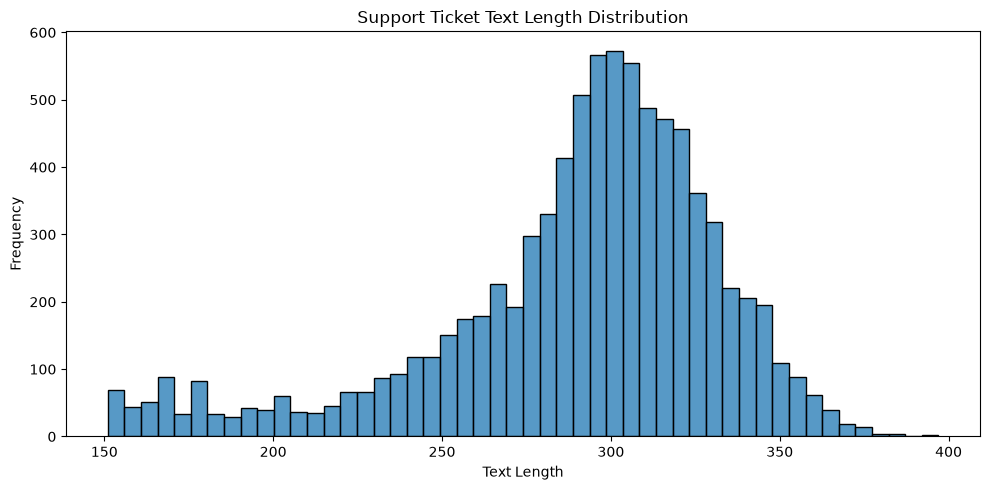

In [18]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["text_length"],
    bins=50
)

plt.title("Support Ticket Text Length Distribution")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## NLP PREPROCESSING

## Text Cleaning Function

In [20]:
import re
import string

def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Apply cleaning
df["clean_text"] = df[TEXT_COLUMN].astype(str).apply(clean_text)

# Show output
print("Text cleaning completed successfully!\n")

display(
    df[[TEXT_COLUMN, "clean_text"]].head(10)
)

Text cleaning completed successfully!



,Ticket Description,clean_text
0,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...
1,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...
2,I'm facing a problem with my {product_purchase...,im facing a problem with my productpurchased t...
3,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...
4,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...
5,I'm facing a problem with my {product_purchase...,im facing a problem with my productpurchased t...
6,I'm unable to access my {product_purchased} ac...,im unable to access my productpurchased accoun...
7,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...
8,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...
9,My {product_purchased} is making strange noise...,my productpurchased is making strange noises a...


## Apply NLP Cleaning

In [21]:
df["clean_text"] = df[TEXT_COLUMN].apply(clean_text)

display(
    df[
        [
            TEXT_COLUMN,
            "clean_text"
        ]
    ].head(10)
)

,Ticket Description,clean_text
0,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...
1,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...
2,I'm facing a problem with my {product_purchase...,im facing a problem with my productpurchased t...
3,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...
4,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...
5,I'm facing a problem with my {product_purchase...,im facing a problem with my productpurchased t...
6,I'm unable to access my {product_purchased} ac...,im unable to access my productpurchased accoun...
7,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...
8,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...
9,My {product_purchased} is making strange noise...,my productpurchased is making strange noises a...


## Compare Original vs Cleaned Text

In [22]:
for i in range(min(5, len(df))):

    print("ORIGINAL:")
    print(df.iloc[i][TEXT_COLUMN])

    print("\nCLEANED:")
    print(df.iloc[i]["clean_text"])

    print("\n" + "="*80 + "\n")

ORIGINAL:
I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.

CLEANED:
im having an issue with the productpurchased please assist your billing zip code is 71701 we appreciate that you have requested a website address please double check your email address ive tried troubleshooting steps mentioned in the user manual but the issue persists


ORIGINAL:
I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing product.

I'm having an issue with the {product_purchased}. Please assist.

If The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.

CLEANED:
im having an issue with the productpurchased please assist if you need to change an existing product im having an issue w

## MOST FREQUENT WORDS

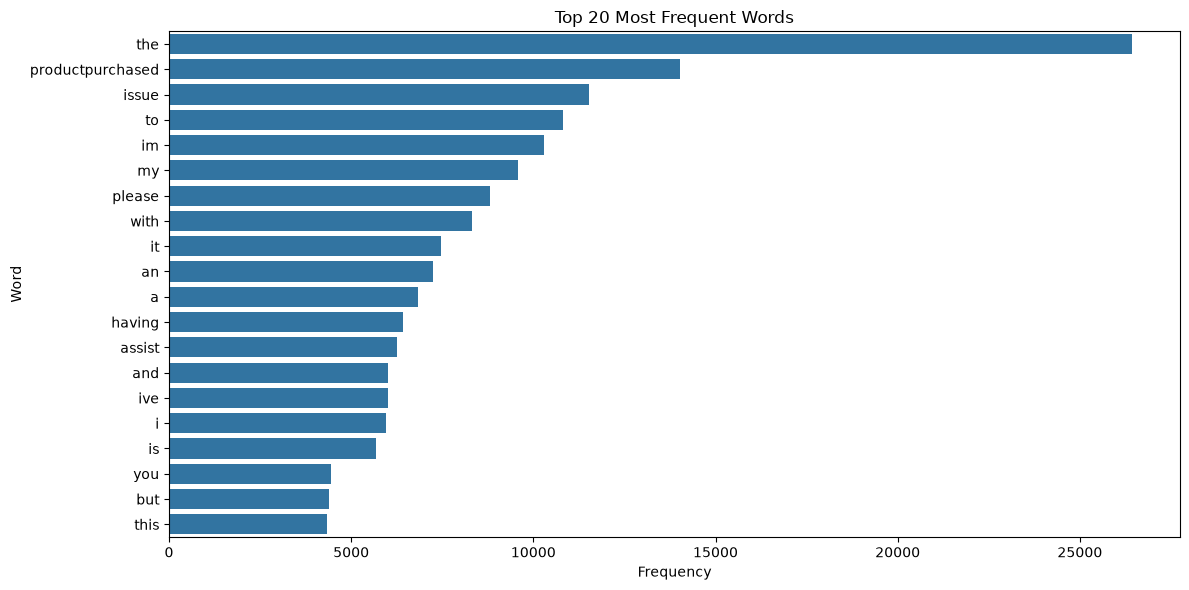

In [23]:
all_words = " ".join(
    df["clean_text"]
).split()

word_counts = Counter(all_words)

most_common_words = word_counts.most_common(20)

words = [x[0] for x in most_common_words]
counts = [x[1] for x in most_common_words]

plt.figure(figsize=(12, 6))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

## CATEGORY CLASSIFICATION

### Prepare Category Data

In [24]:
X = df["clean_text"]
y = df[CATEGORY_COLUMN]

print("Number of samples:", len(X))
print("Number of categories:", y.nunique())

print("\nCategories:")
print(y.unique())

Number of samples: 8469
Number of categories: 5

Categories:
<ArrowStringArray>
[     'Technical issue',      'Billing inquiry', 'Cancellation request',
      'Product inquiry',       'Refund request']
Length: 5, dtype: str


### Train/Test Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 6775
Testing Samples: 1694


## TF-IDF

### TF-IDF Transformation

In [26]:
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print(
    "Training TF-IDF Shape:",
    X_train_tfidf.shape
)

print(
    "Testing TF-IDF Shape:",
    X_test_tfidf.shape
)

Training TF-IDF Shape: (6775, 13890)
Testing TF-IDF Shape: (1694, 13890)


## MACHINE LEARNING MODELS

### Logistic Regression

In [27]:
lr_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

lr_pred = lr_model.predict(
    X_test_tfidf
)

lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

lr_f1 = f1_score(
    y_test,
    lr_pred,
    average="weighted"
)

print("Logistic Regression")
print("Accuracy:", lr_accuracy)
print("Weighted F1:", lr_f1)

Logistic Regression
Accuracy: 0.19952774498229045
Weighted F1: 0.19900543082728345


### Naive Bayes

In [28]:
nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

nb_pred = nb_model.predict(
    X_test_tfidf
)

nb_accuracy = accuracy_score(
    y_test,
    nb_pred
)

nb_f1 = f1_score(
    y_test,
    nb_pred,
    average="weighted"
)

print("Naive Bayes")
print("Accuracy:", nb_accuracy)
print("Weighted F1:", nb_f1)

Naive Bayes
Accuracy: 0.2001180637544274
Weighted F1: 0.19276564903564905


### Linear SVM

In [29]:
svm_model = LinearSVC(
    class_weight="balanced"
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_pred = svm_model.predict(
    X_test_tfidf
)

svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

svm_f1 = f1_score(
    y_test,
    svm_pred,
    average="weighted"
)

print("Linear SVM")
print("Accuracy:", svm_accuracy)
print("Weighted F1:", svm_f1)

Linear SVM
Accuracy: 0.19539551357733176
Weighted F1: 0.1954635732510821


### Random Forest

In [30]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(
    X_train_tfidf,
    y_train
)

rf_pred = rf_model.predict(
    X_test_tfidf
)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="weighted"
)

print("Random Forest")
print("Accuracy:", rf_accuracy)
print("Weighted F1:", rf_f1)

Random Forest
Accuracy: 0.19657615112160567
Weighted F1: 0.195919317141614


## MODEL COMPARISON

In [31]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Linear SVM",
        "Random Forest"
    ],

    "Accuracy": [
        lr_accuracy,
        nb_accuracy,
        svm_accuracy,
        rf_accuracy
    ],

    "Weighted F1": [
        lr_f1,
        nb_f1,
        svm_f1,
        rf_f1
    ]
})

results = results.sort_values(
    "Weighted F1",
    ascending=False
)

display(results)

,Model,Accuracy,Weighted F1
0,Logistic Regression,0.199528,0.199005
3,Random Forest,0.196576,0.195919
2,Linear SVM,0.195396,0.195464
1,Naive Bayes,0.200118,0.192766


## Model Comparison Graph

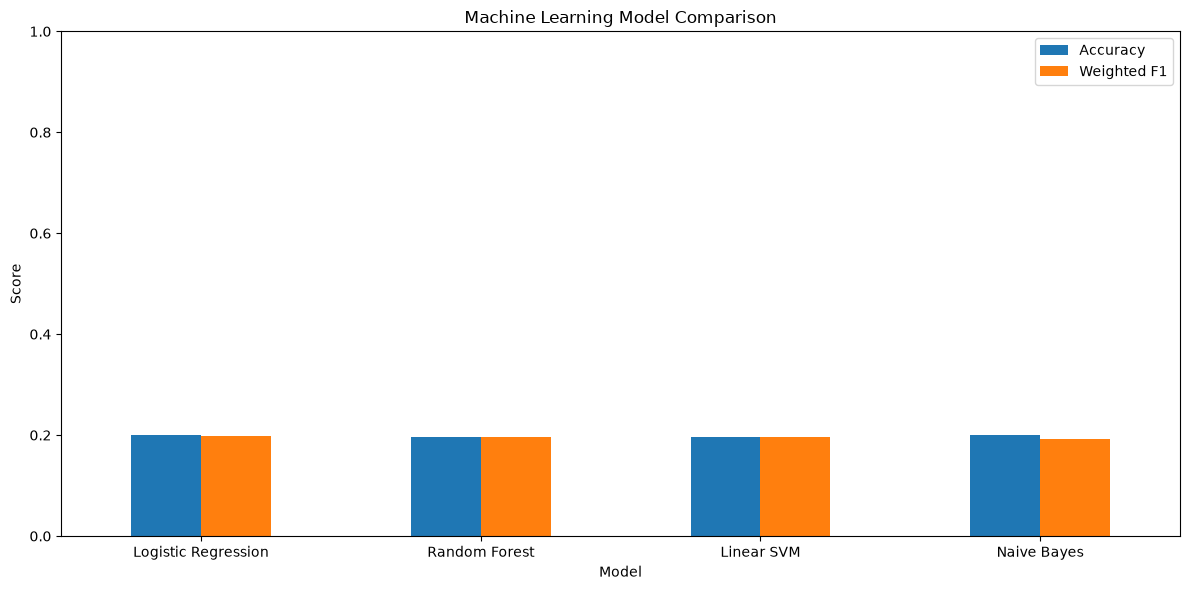

In [32]:
results_plot = results.set_index("Model")

results_plot[
    ["Accuracy", "Weighted F1"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## BEST MODEL


In [33]:
best_model_name = results.iloc[0]["Model"]

print("BEST MODEL:")
print(best_model_name)

BEST MODEL:
Logistic Regression


## Select Best Model

In [34]:
models = {
    "Logistic Regression": lr_model,
    "Naive Bayes": nb_model,
    "Linear SVM": svm_model,
    "Random Forest": rf_model
}

best_model = models[best_model_name]

best_predictions = best_model.predict(
    X_test_tfidf
)

print("Best model selected successfully!")

Best model selected successfully!


## DETAILED EVALUATION

### Classification Report

In [35]:
print(
    classification_report(
        y_test,
        best_predictions
    )
)

                      precision    recall  f1-score   support

     Billing inquiry       0.20      0.23      0.21       327
Cancellation request       0.17      0.17      0.17       339
     Product inquiry       0.21      0.23      0.22       328
      Refund request       0.20      0.19      0.19       351
     Technical issue       0.21      0.18      0.19       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694



### Confusion Matrix

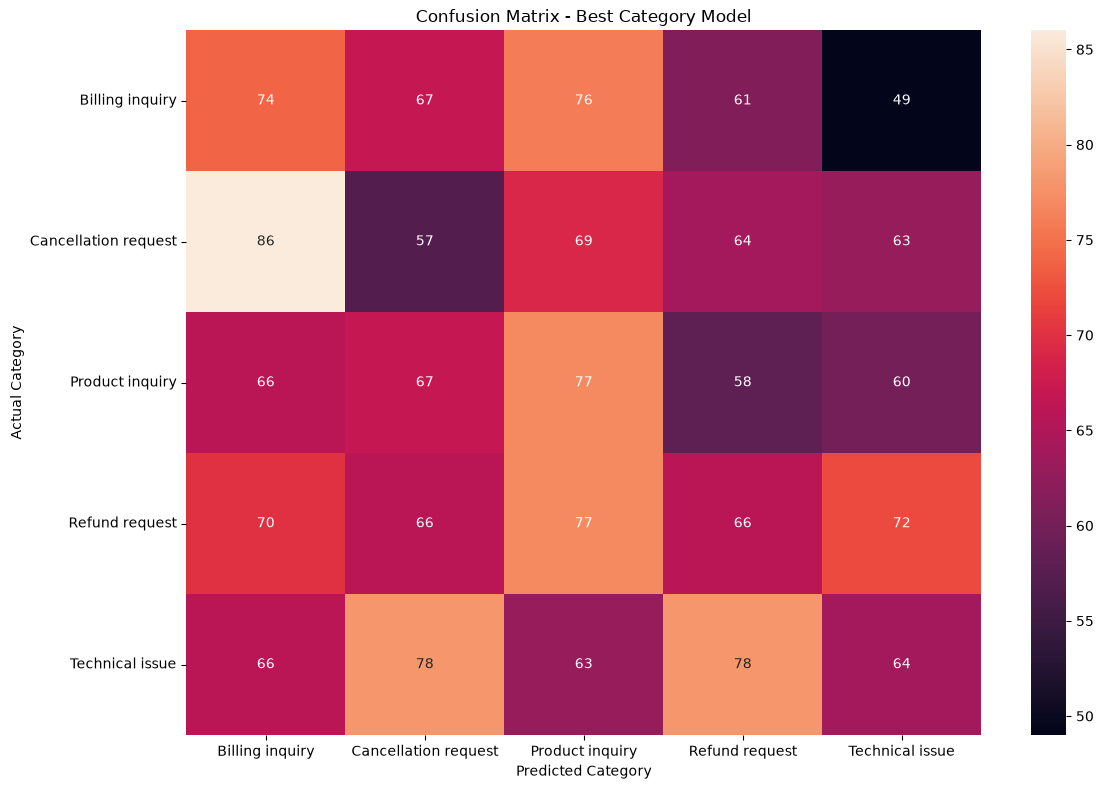

In [36]:
cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=sorted(y.unique()),
    yticklabels=sorted(y.unique())
)

plt.title(
    "Confusion Matrix - Best Category Model"
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")

plt.tight_layout()
plt.show()

## HYPERPARAMETER TUNING

In [37]:
svm_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LinearSVC(
            class_weight="balanced"
        )
    )
])

## Grid Search

In [38]:
param_grid = {
    "tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],

    "tfidf__max_features": [
        5000,
        10000,
        15000
    ],

    "classifier__C": [
        0.5,
        1,
        2
    ]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.5, 1, ...], 'tfidf__max_features': [5000, 10000, ...], 'tfidf__ngram_range': [(1, ...), (1, ...)]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluat

## Best Parameters

In [39]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1:")
print(grid_search.best_score_)

Best Parameters:
{'classifier__C': 2, 'tfidf__max_features': 15000, 'tfidf__ngram_range': (1, 2)}

Best Cross-Validation F1:
0.20210759334674117


## Tuned Model Evaluation

In [40]:
tuned_model = grid_search.best_estimator_

tuned_predictions = tuned_model.predict(
    X_test
)

tuned_accuracy = accuracy_score(
    y_test,
    tuned_predictions
)

tuned_f1 = f1_score(
    y_test,
    tuned_predictions,
    average="weighted"
)

print("Tuned Model Accuracy:", tuned_accuracy)
print("Tuned Model Weighted F1:", tuned_f1)

Tuned Model Accuracy: 0.19893742621015348
Tuned Model Weighted F1: 0.1988142224839429


## PRIORITY PREDICTION

### Prepare Priority Dataset

In [41]:
X_priority = df["clean_text"]

y_priority = df[PRIORITY_COLUMN]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_priority,
    y_priority,
    test_size=0.20,
    random_state=42,
    stratify=y_priority
)

print("Priority Classes:")
print(y_priority.value_counts())

Priority Classes:
Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


## Priority Model

In [42]:
priority_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=15000,
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),

    (
        "classifier",
        LinearSVC(
            class_weight="balanced"
        )
    )
])

priority_pipeline.fit(
    X_train_p,
    y_train_p
)

priority_predictions = priority_pipeline.predict(
    X_test_p
)

print(
    "Priority Accuracy:",
    accuracy_score(
        y_test_p,
        priority_predictions
    )
)

print(
    "\nPriority Classification Report:\n"
)

print(
    classification_report(
        y_test_p,
        priority_predictions
    )
)

Priority Accuracy: 0.23907910271546634

Priority Classification Report:

              precision    recall  f1-score   support

    Critical       0.23      0.22      0.23       426
        High       0.23      0.24      0.24       417
         Low       0.23      0.25      0.24       413
      Medium       0.26      0.24      0.25       438

    accuracy                           0.24      1694
   macro avg       0.24      0.24      0.24      1694
weighted avg       0.24      0.24      0.24      1694



## SENTIMENT ANALYSIS

### Install TextBlob


In [43]:
!pip install textblob

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 2.0 MB/s  0:00:00


## Sentiment Analysis

In [44]:
from textblob import TextBlob

def get_sentiment(text):

    polarity = TextBlob(
        str(text)
    ).sentiment.polarity

    if polarity > 0.1:
        sentiment = "Positive"

    elif polarity < -0.1:
        sentiment = "Negative"

    else:
        sentiment = "Neutral"

    return sentiment

## Apply Sentiment Analysis

In [45]:
df["sentiment"] = df[TEXT_COLUMN].apply(
    get_sentiment
)

display(
    df[
        [
            TEXT_COLUMN,
            "sentiment"
        ]
    ].head(10)
)

,Ticket Description,sentiment
0,I'm having an issue with the {product_purchase...,Neutral
1,I'm having an issue with the {product_purchase...,Positive
2,I'm facing a problem with my {product_purchase...,Positive
3,I'm having an issue with the {product_purchase...,Positive
4,I'm having an issue with the {product_purchase...,Neutral
5,I'm facing a problem with my {product_purchase...,Positive
6,I'm unable to access my {product_purchased} ac...,Negative
7,I'm having an issue with the {product_purchase...,Neutral
8,I'm having an issue with the {product_purchase...,Neutral
9,My {product_purchased} is making strange noise...,Neutral


## Sentiment Distribution

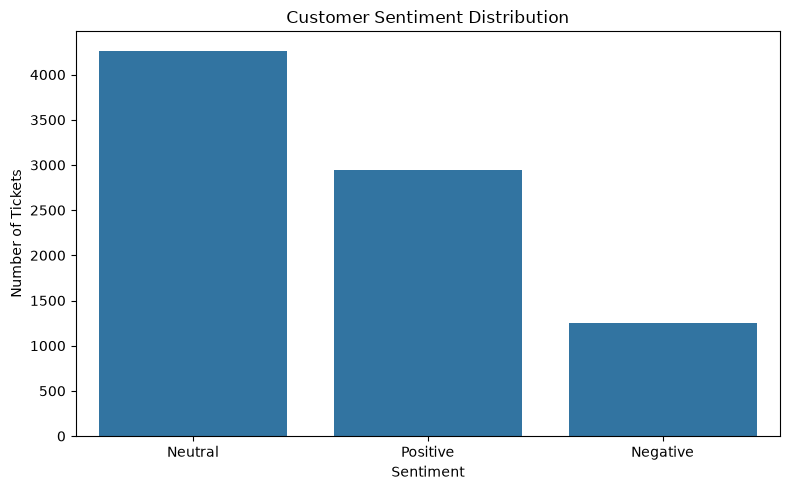

In [46]:
plt.figure(figsize=(8, 5))

sentiment_counts = df["sentiment"].value_counts()

sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tickets")

plt.tight_layout()
plt.show()

## SMART ROUTING

## Support Team Routing

In [47]:
def recommend_team(category):

    category_text = str(category).lower()

    if any(
        word in category_text
        for word in [
            "payment",
            "billing",
            "refund",
            "invoice"
        ]
    ):
        return "Billing Team"

    elif any(
        word in category_text
        for word in [
            "technical",
            "technical issue",
            "bug",
            "error",
            "software"
        ]
    ):
        return "Technical Support"

    elif any(
        word in category_text
        for word in [
            "account",
            "login",
            "password"
        ]
    ):
        return "Account Support"

    elif any(
        word in category_text
        for word in [
            "delivery",
            "shipping",
            "order"
        ]
    ):
        return "Logistics Team"

    else:
        return "General Support"

## COMPLETE AI PREDICTION

### Prediction Function

In [48]:
def analyze_ticket(ticket):

    cleaned_ticket = clean_text(ticket)

    # Category
    category = tuned_model.predict(
        [cleaned_ticket]
    )[0]

    # Priority
    priority = priority_pipeline.predict(
        [cleaned_ticket]
    )[0]

    # Sentiment
    sentiment = get_sentiment(
        ticket
    )

    # Team
    team = recommend_team(
        category
    )

    # Confidence
    confidence = None

    if hasattr(
        tuned_model.named_steps["classifier"],
        "decision_function"
    ):
        decision = tuned_model.decision_function(
            [cleaned_ticket]
        )

        if decision.ndim == 1:
            confidence = abs(decision[0])

        else:
            confidence = np.max(decision)

    return {
        "Category": category,
        "Priority": priority,
        "Sentiment": sentiment,
        "Recommended Team": team,
        "Confidence Score": confidence
    }

## TEST THE AI


In [49]:
new_ticket = """
My payment was deducted from my bank account,
but my order is still showing as pending.
I need this issue resolved urgently.
"""

result = analyze_ticket(
    new_ticket
)

print("CUSTOMER TICKET")
print("-" * 60)
print(new_ticket)

print("\nAI ANALYSIS")
print("-" * 60)

for key, value in result.items():
    print(f"{key}: {value}")

CUSTOMER TICKET
------------------------------------------------------------

My payment was deducted from my bank account,
but my order is still showing as pending.
I need this issue resolved urgently.


AI ANALYSIS
------------------------------------------------------------
Category: Refund request
Priority: Critical
Sentiment: Neutral
Recommended Team: Billing Team
Confidence Score: 0.6769606566180529


## TEST MULTIPLE TICKETS

In [50]:
test_tickets = [
    "I forgot my password and cannot login to my account.",
    
    "My payment was deducted twice from my account.",
    
    "The application crashes whenever I upload a document.",
    
    "My order has not arrived yet and the delivery is delayed.",
    
    "I am very happy with your customer service."
]

for i, ticket in enumerate(
    test_tickets,
    start=1
):

    result = analyze_ticket(ticket)

    print("=" * 80)
    print(f"TICKET {i}")
    print(ticket)

    print("\nCategory:",
          result["Category"])

    print("Priority:",
          result["Priority"])

    print("Sentiment:",
          result["Sentiment"])

    print("Recommended Team:",
          result["Recommended Team"])

TICKET 1
I forgot my password and cannot login to my account.

Category: Cancellation request
Priority: High
Sentiment: Neutral
Recommended Team: General Support
TICKET 2
My payment was deducted twice from my account.

Category: Technical issue
Priority: Low
Sentiment: Neutral
Recommended Team: Technical Support
TICKET 3
The application crashes whenever I upload a document.

Category: Refund request
Priority: Critical
Sentiment: Neutral
Recommended Team: Billing Team
TICKET 4
My order has not arrived yet and the delivery is delayed.

Category: Refund request
Priority: Medium
Sentiment: Neutral
Recommended Team: Billing Team
TICKET 5
I am very happy with your customer service.

Category: Refund request
Priority: High
Sentiment: Positive
Recommended Team: Billing Team


## ERROR ANALYSIS

In [51]:
error_analysis = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": tuned_predictions,
    "Text": X_test.values
})

errors = error_analysis[
    error_analysis["Actual"] !=
    error_analysis["Predicted"]
]

print(
    "Total incorrect predictions:",
    len(errors)
)

display(
    errors.head(20)
)

Total incorrect predictions: 1357


,Actual,Predicted,Text
0,Product inquiry,Cancellation request,im having an issue with the productpurchased p...
2,Billing inquiry,Cancellation request,im having an issue with the productpurchased p...
3,Product inquiry,Technical issue,im having an issue with the productpurchased p...
4,Refund request,Billing inquiry,im having an issue with the productpurchased p...
5,Cancellation request,Technical issue,im having an issue with the productpurchased p...
6,Technical issue,Refund request,im having an issue with the productpurchased p...
8,Refund request,Technical issue,im facing issues logging into my productpurcha...
9,Billing inquiry,Cancellation request,im having an issue with the productpurchased p...
11,Technical issue,Product inquiry,my productpurchased is making strange noises a...
12,Cancellation request,Technical issue,there seems to be a glitch in the productpurch...


## Most Confused Categories

In [52]:
confusion_pairs = (
    errors.groupby(
        ["Actual", "Predicted"]
    )
    .size()
    .reset_index(
        name="Count"
    )
    .sort_values(
        "Count",
        ascending=False
    )
)

display(
    confusion_pairs.head(15)
)

,Actual,Predicted,Count
15,Refund request,Technical issue,81
13,Refund request,Cancellation request,79
19,Technical issue,Refund request,78
9,Product inquiry,Cancellation request,78
2,Billing inquiry,Refund request,74
18,Technical issue,Product inquiry,70
11,Product inquiry,Technical issue,70
4,Cancellation request,Billing inquiry,70
1,Billing inquiry,Product inquiry,69
16,Technical issue,Billing inquiry,69


## SAVE MODELS

In [53]:
import os

os.makedirs(
    "models",
    exist_ok=True
)

joblib.dump(
    tuned_model,
    "models/category_model.pkl"
)

joblib.dump(
    priority_pipeline,
    "models/priority_model.pkl"
)

print("Models saved successfully!")

Models saved successfully!


## SAVE PROCESSED DATA

In [54]:
os.makedirs(
    "outputs",
    exist_ok=True
)

df.to_csv(
    "outputs/processed_support_tickets.csv",
    index=False
)

results.to_csv(
    "outputs/model_comparison.csv",
    index=False
)

print("Output files saved successfully!")

Output files saved successfully!


## FINAL MODEL SUMMARY

In [55]:
final_results = pd.DataFrame({
    "Metric": [
        "Tuned Model Accuracy",
        "Tuned Model Weighted F1",
        "Priority Accuracy"
    ],

    "Score": [
        tuned_accuracy,
        tuned_f1,
        accuracy_score(
            y_test_p,
            priority_predictions
        )
    ]
})

display(final_results)

,Metric,Score
0,Tuned Model Accuracy,0.198937
1,Tuned Model Weighted F1,0.198814
2,Priority Accuracy,0.239079


## FINAL DEMONSTRATION


In [ ]:
ticket = input(
    "Enter a customer support ticket: "
)

result = analyze_ticket(ticket)

print("\n" + "=" * 60)
print("AI SUPPORT TICKET ANALYSIS")
print("=" * 60)

print("Category:",
      result["Category"])

print("Priority:",
      result["Priority"])

print("Sentiment:",
      result["Sentiment"])

print("Recommended Team:",
      result["Recommended Team"])

print("Confidence Score:",
      result["Confidence Score"])

print("=" * 60)


<div style="
background-color:#F3E5F5;
padding:20px;
border-radius:10px;
border-left:5px solid #9C27B0;
">

<h2 style="color:#6A1B9A; margin-top:0;">
Conclusion
</h2>

<p style="color:#333333; font-size:16px; line-height:1.6;">
The AI-Powered Support Ticket Classification and Prioritization system
successfully demonstrates the application of Natural Language Processing
and Machine Learning to automate customer support operations.
</p>

</div>


## Major Achievements

- Performed comprehensive exploratory data analysis.
- Cleaned and preprocessed customer support text.
- Converted natural language into numerical TF-IDF features.
- Compared multiple Machine Learning algorithms.
- Selected the best-performing classification model.
- Performed hyperparameter optimization using GridSearchCV.
- Classified support tickets automatically.
- Predicted ticket priority.
- Performed customer sentiment analysis.
- Implemented automated support-team routing.
- Performed confusion-matrix and classification-report analysis.
- Performed error analysis on incorrectly classified tickets.
- Created a real-time ticket prediction function.
- Saved trained models for future deployment.

## Business Value

The proposed system can help customer support organizations:

1. Reduce manual ticket classification.
2. Identify urgent tickets faster.
3. Automatically route tickets to appropriate teams.
4. Understand customer sentiment.
5. Improve response time.
6. Increase support-team efficiency.
7. Provide consistent ticket prioritization.

## Future Enhancements

Future versions can integrate:

- Transformer-based NLP models.
- BERT/RoBERTa.
- Large Language Models.
- Automatic response generation.
- Multilingual ticket classification.
- Real-time API deployment.
- Cloud deployment.
- Production monitoring.

### Final Outcome

The project demonstrates an end-to-end Machine Learning workflow from
raw customer support data to an intelligent ticket analysis system.